In [62]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

from numpy.typing import NDArray
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
from scipy.optimize import curve_fit
from pybaselines import Baseline
import scienceplots
import damnit

from analysis.utils import (
    RHO_WATER_25C,
    deff_sq_to_volume,
    droplet_composition,
    fit_D2_law,
    gauss,
    get_train_timestamps,
    log_interpolate,
    piecewise_D2,
    read_intensity,
    read_volume,
    read_volume_series,
    style_plot,
    droplet_scaling
)

plt.style.use('science')


def clean_range(run_range: list) -> list:
    try:
        if run_range[0] == 443:
            run_range.remove(447)
        elif run_range[0] == 338:
            [run_range.remove(i) for i in [349, 353, 354, 355, 356]]
    except:
        pass
    finally:
        return run_range

In [63]:
db = damnit.Damnit(10400)

In [64]:
from analysis import cache

# Background: the buffer droplet r464 -> r465 -> r466 (PEG 6K 5 % + 150 mM NaCl, fresh in r464),
# matched to each sample train at the same normalised time t/t*. r463 is left out (a bubble made
# it explode). The buffer's D^2 law never breaks before the droplet goes unstable in r466, so its
# t* is the end of its clean data: the timeline stops at the smallest volume, t_star="end".
# Both the SAXS data and the timelines come from the cache (analysis.cache, scratch/saxs_cache):
# unscaled and unsubtracted, with the scale factors stored beside them and applied only here.
BG_RUNS = [464, 465, 466]
BG_BIN = 100  # consecutive complete trains per buffer bin
N_PULSES = 155  # pulses per train averaged in the cache (and in the XGM normalisation)

bg_tl = cache.droplet_timeline(BG_RUNS, db, stop_at_min_volume=True, t_star="end")
bg_runs = xr.concat(
    [cache.saxs_run(r, db, v0_run=BG_RUNS[0], ferritin_mg_per_ml_initial=0) for r in BG_RUNS],
    "trainId",
    combine_attrs="drop",
)
bg_tau = (bg_tl.elapsed_s / bg_tl.attrs["t_star_s"]).where(bg_tl.used_in_fit)

# complete trains with a scale factor and a t/t* before the droplet was lost, in time order
usable = (bg_runs.n_pulses_with_frames == N_PULSES) & np.isfinite(bg_runs.scale)
tids = np.intersect1d(bg_runs.trainId.values[usable.values], bg_tau.trainId.values[np.isfinite(bg_tau.values)])
b = bg_runs.sel(trainId=tids)
n_bins = tids.size // BG_BIN
kept = slice(0, n_bins * BG_BIN)
bg_lib = xr.DataArray(
    np.nanmean((b.intensity * b.scale).values[kept].reshape(n_bins, BG_BIN, -1), axis=1),
    dims=("tau", "q"),
    coords={"tau": bg_tau.sel(trainId=tids).values[kept].reshape(n_bins, BG_BIN).mean(1), "q": b.q.values},
).sortby("tau")
assert np.all(np.diff(bg_lib.tau) > 0), "buffer bins are not monotonic in t/t*"
BG_T_ATT = float(np.unique(np.round(b.total_transmission.values, 4)).item())
print(f"buffer: t* = {bg_tl.attrs['t_star_s']:.0f} s ({bg_tl.attrs['t_star_source']}), {n_bins} bins over "
      f"t/t* {float(bg_lib.tau.min()):.3f}-{float(bg_lib.tau.max()):.3f}, attenuator {BG_T_ATT}")

ImportError: cannot import name 'cache' from 'analysis' (/home/andronis/MID-10400/src/analysis/__init__.py)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
bg_norm = mpl.colors.Normalize(vmin=float(bg_lib.tau.min()), vmax=float(bg_lib.tau.max()))
for tau in bg_lib.tau.values[:: max(1, n_bins // 12)]:
    ax.loglog(bg_lib.q, bg_lib.sel(tau=tau), color=plt.cm.plasma(bg_norm(tau)), lw=0.8)
fig.colorbar(mpl.cm.ScalarMappable(norm=bg_norm, cmap="plasma"), ax=ax, label="buffer $t/t^*$")
ax.set_title(f"buffer r{BG_RUNS[0]}-{BG_RUNS[-1]}", fontsize=14)
style_plot(ax, ylabel=r"$I(q)$ per flux$\cdot$path")
fig.tight_layout()
plt.show()

In [ ]:
# Lowest trustworthy q per curve. Below it the three chi sectors of the unmasked wedge stop
# agreeing, because the droplet shadows the stray scatter near the beam; measured on r443-452
# (2026-09-29) it scales with the droplet's horizontal semi-axis a_x. The floor covers the 4 of
# 15 plateau blocks that already disagreed at 0.105-0.114 nm^-1.
Q_MIN_PER_MM = 0.156  # nm^-1 per mm of a_x
Q_MIN_FLOOR = 0.11  # nm^-1
# At attenuator 0.506 everything per logged flux (the stray-light streak and the droplet's own
# scattering) reads ~1.3x the attenuator-1.0 runs (2026-09-29, r467/477/487 vs r443/453). The
# sample is divided by this, which puts it on the buffer's scale.
FLUX_CORR = {0.506: 1.3}
N_AVG = 10  # consecutive complete trains averaged per curve


def flux_corr(t_att):
    if np.isclose(t_att, BG_T_ATT, rtol=0.01):
        return 1.0
    for att, corr in FLUX_CORR.items():
        if np.isclose(t_att, att, rtol=0.01):
            return corr
    raise ValueError(f"no flux correction known for attenuator {t_att} (buffer: {BG_T_ATT})")


def subtract(s, tau):
    """Buffer-subtracted I(q) per flux*path for the trains in `s`, each at its own t/t*."""
    corr = xr.DataArray([flux_corr(t) for t in s.total_transmission.values], coords={"trainId": s.trainId})
    bg = bg_lib.interp(tau=tau.clip(bg_lib.tau.min(), bg_lib.tau.max()))
    return (s.intensity * s.scale / corr - (1 - s.phi_ferritin) * bg).mean("trainId")


# The whole droplet sets t* and V0; run_range only picks which of its runs to plot.
droplet_runs = clean_range(list(range(443, 453)))
run_range = clean_range(list(range(443, 444)))
tl = cache.droplet_timeline(droplet_runs, db)
t_star = tl.attrs["t_star_s"]
tau_s = tl.elapsed_s / t_star
print(f"sample: t* = {t_star:.0f} s ({tl.attrs['t_star_source']}); t/t* up to {float(tau_s.max()):.2f}")

curves_per_run = 3
curves = []  # (t/t*, q_min, subtracted I(q) per flux*path)
for run_nr in run_range:
    ds = cache.saxs_run(run_nr, db, v0_run=droplet_runs[0])
    # complete trains that have a scale factor and a t/t*, picked by label, never by position
    usable = (ds.n_pulses_with_frames == N_PULSES) & np.isfinite(ds.scale)
    tids = np.intersect1d(ds.trainId.values[usable.values], tau_s.trainId.values)
    for i in np.linspace(0, len(tids) - N_AVG, curves_per_run).round().astype(int):
        block = tids[i : i + N_AVG]
        tau = tau_s.sel(trainId=block)
        a_x = float(ds.chord_mm.sel(trainId=block).mean()) / 2
        curves.append(
            (float(tau.mean()), max(Q_MIN_PER_MM * a_x, Q_MIN_FLOOR), subtract(ds.sel(trainId=block), tau))
        )
beyond = sum(t > float(bg_lib.tau.max()) for t, _, _ in curves)
print(f"{len(curves)} curves; {beyond} lie beyond the buffer's t/t* = {float(bg_lib.tau.max()):.2f} "
      "and use its final state")

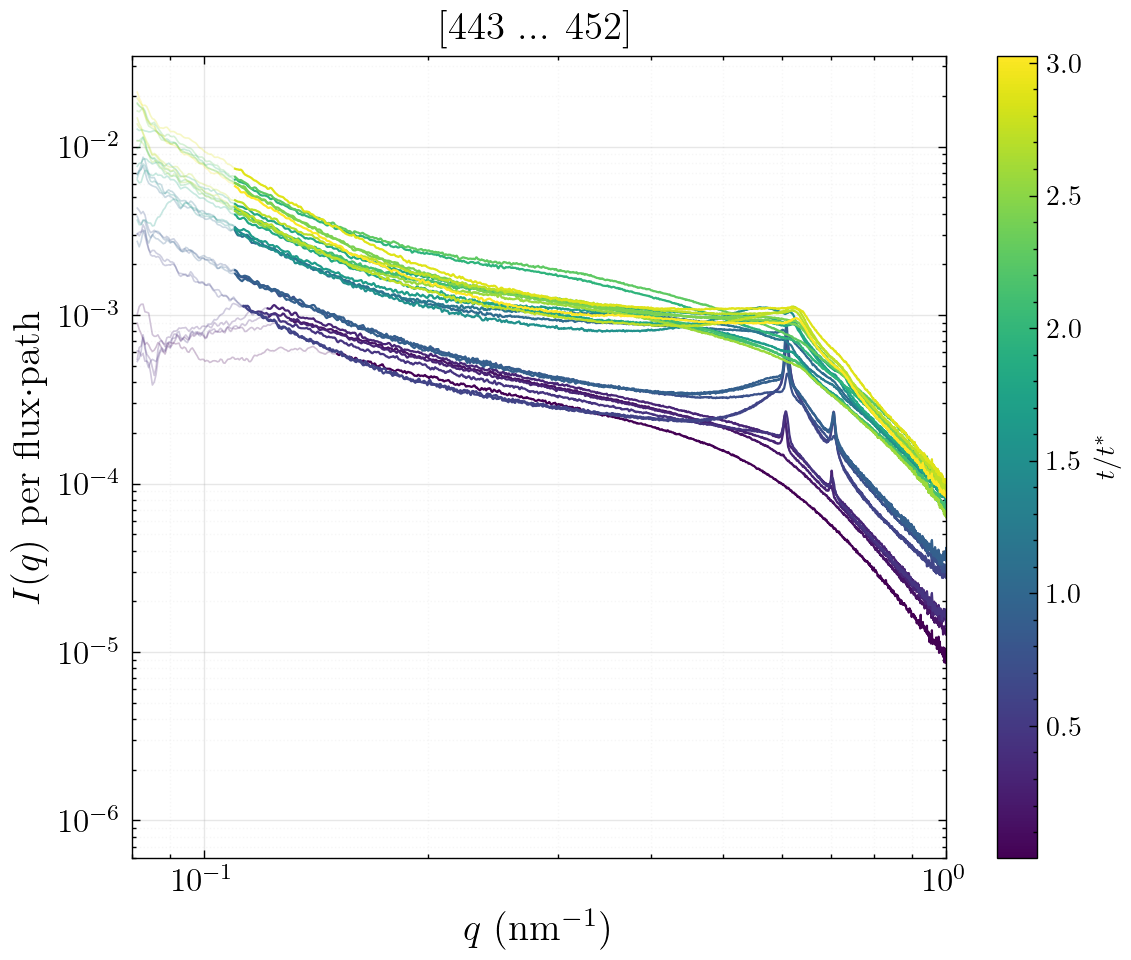

In [73]:
NORMALISE = False  # True: divide each curve by its mean over 0.80-0.95 nm^-1
SHOW_BELOW_QMIN = True  # draw the untrusted part below q_min faintly, for reference

cmap = plt.get_cmap("viridis")
norm = mpl.colors.Normalize(vmin=min(t for t, _, _ in curves), vmax=max(t for t, _, _ in curves))

fig, ax = plt.subplots(figsize=(6, 5))
for t, q_min, iq in curves:
    if NORMALISE:
        iq = iq / iq.sel(q=slice(0.80, 0.95)).mean()
    iq = iq.where(iq > 0)
    ax.loglog(iq.q, iq.where(iq.q >= q_min), color=cmap(norm(t)), lw=0.8)
    if SHOW_BELOW_QMIN:
        ax.loglog(iq.q, iq.where(iq.q <= q_min), color=cmap(norm(t)), lw=0.6, alpha=0.25)
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="$t/t^*$")
ax.set_title(f"[{run_range[0]} ... {run_range[-1]}]", fontsize=14)
ylabel = r"$I(q)\,/\,\langle I \rangle_{0.80-0.95}$" if NORMALISE else r"$I(q)$ per flux$\cdot$path"
style_plot(ax, ylabel=ylabel)
ax.set_xlim(0.08, 1.0)  # the last bins at the detector edge are noisy
fig.tight_layout()
plt.savefig(f"r{run_range[0]}-{run_range[-1]}_saxs_all.png", dpi=300, bbox_inches="tight")
plt.show()

(0.15, 1.0)

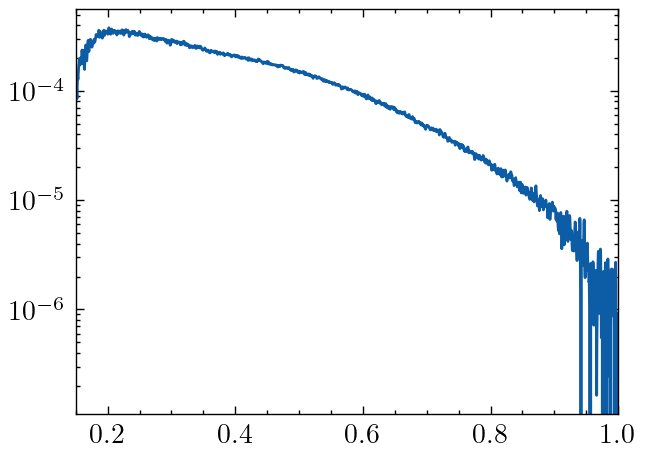

In [61]:
plt.semilogy(iq.q, iq[0] - bg_lib[0]*5)
plt.xlim(0.15, 1)
# plt.loglog(bg_lib.q, bg_lib[0]*1.3)